# CS 229 - Homework 2: Confident Emoji Hunter

Submit **PDF** of completed notebook on Canvas.

**Maximum points**: 15

<div style="margin-bottom: 15px; padding: 15px; color: #31708f; background-color: #d9edf7; border: 1px solid #bce8f1; border-radius: 5px;">

<b><font size=+2>Enter your information below:</font></b><br/><br/>

  <b>(full) Name</b>: Vedant Deepak Borkute
  <br/>
  <b>Student ID Number</b>:  862552981
  <br/><br/>

<b>By submitting this notebook, I assert that the work below is my own work. Except where explicitly cited, none of the portions of this notebook are duplicated from anyone else's work.</b>
</div>

# Overview

Neural networks are often **overconfident** — they assign high probability to their predictions even when they're wrong. This is a serious problem in safety-critical applications (medical diagnosis, autonomous driving, etc.).

In this assignment you will:
1. Train an image classifier using frozen [DINOv2](https://arxiv.org/abs/2304.07193) features
2. Measure how well calibrated its confidence is
3. Compare three methods for improving calibration:
   - **Temperature scaling** (post-hoc)
   - **MC Dropout** (inference-time)
   - **Label smoothing** (train-time)

These methods are evaluated **independently** — do not combine them.

### The Emoji Hunter Task

Your dataset contains 128×128 natural images. Half have a [Twemoji](https://github.com/jdecked/twemoji) (e.g. fire, rocket, ghost, pizza) overlaid with varying size and transparency. Your job: classify which images contain an emoji. Some emojis are large and obvious; others are small and nearly transparent — making the model's confidence particularly interesting to study.

Complete all parts marked `TODO` and ensure all test cells produce the expected output.

## Setup
Run these cells to load the model and data. **Do not modify.**

In [16]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps') if torch.backends.mps.is_available() else device
print(f'Using device: {device}')

torch.manual_seed(229)

Using device: cuda


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

Download `hw2_data.pt` from Canvas and place it in the same directory as this notebook.

The dataset contains 128×128 natural images (from STL-10). Half have a Twemoji overlaid with varying size and transparency. Your task is to classify which images contain an emoji.

In [19]:
data = torch.load('/content/drive/My Drive/CS229/hw2_data.pt', weights_only=False)
train_images = data['train_images']   # (1200, 3, 128, 128) uint8
train_labels = data['train_labels']   # (1200,) long: 0=clean, 1=emoji
test_images = data['test_images']     # (400, 3, 128, 128) uint8
test_labels = data['test_labels']     # (400,) long

print(f'Train: {len(train_images)} images ({train_labels.sum().item()} emoji, {(train_labels == 0).sum().item()} clean)')
print(f'Test:  {len(test_images)} images ({test_labels.sum().item()} emoji, {(test_labels == 0).sum().item()} clean)')
print(f'Image shape: {train_images.shape[1:]}, dtype: {train_images.dtype}')

Train: 1200 images (598 emoji, 602 clean)
Test:  400 images (202 emoji, 198 clean)
Image shape: torch.Size([3, 128, 128]), dtype: torch.uint8


## Extract DINOv2 Features

We use a frozen [DINOv2](https://arxiv.org/abs/2304.07193) backbone (ViT-Small/14) to extract 384-dimensional feature vectors from each image. These features capture rich visual representations without any task-specific training.

You will train only a small classifier head on top of these frozen features. **Do not modify this cell.**

In [20]:
# Load DINOv2 ViT-Small/14 (downloads ~80MB on first run)
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino = dino.to(device)
dino.eval()
print('DINOv2 ViT-S/14 loaded')

# ImageNet normalization constants
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
IMG_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)


def extract_features(images, batch_size=64):
    """Extract DINOv2 CLS token features from uint8 image tensors."""
    features = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i + batch_size].float() / 255.0
            batch = F.interpolate(batch, size=224, mode='bilinear', align_corners=False)
            batch = (batch.to(device) - IMG_MEAN) / IMG_STD
            feat = dino(batch)
            features.append(feat.cpu())
    return torch.cat(features)


print('Extracting train features...')
train_features = extract_features(train_images)
print('Extracting test features...')
test_features = extract_features(test_images)
print(f'Feature shape: {train_features.shape}')  # (1200, 384)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 ViT-S/14 loaded
Extracting train features...
Extracting test features...
Feature shape: torch.Size([1200, 384])


## Provided Helper: Calibration Plot

This function plots a reliability diagram and prediction distribution. You will call it after computing calibration metrics. **Do not modify.**

In [21]:
def plot_calibration(bin_confidences, bin_accuracies, bin_counts, ece, title='Calibration'):
    """Plot reliability diagram and prediction distribution.
    
    Args:
        bin_confidences: (n_bins,) average confidence per bin
        bin_accuracies: (n_bins,) average accuracy per bin
        bin_counts: (n_bins,) number of predictions per bin
        ece: scalar expected calibration error
        title: plot title prefix
    """
    # Move to CPU/numpy in case tensors are on GPU
    bin_confidences = bin_confidences.detach().cpu()
    bin_accuracies = bin_accuracies.detach().cpu()
    bin_counts = bin_counts.detach().cpu()

    n_bins = len(bin_confidences)
    width = 1.0 / n_bins
    # Only plot bins that have data
    mask = bin_counts > 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    # Reliability diagram
    ax1.bar(bin_confidences[mask], bin_accuracies[mask], width=width * 0.8,
            alpha=0.7, color='steelblue', edgecolor='black', label='Model')
    ax1.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect calibration')
    ax1.set_xlabel('Confidence P(emoji)')
    ax1.set_ylabel('Fraction actually emoji')
    ax1.set_title(f'{title}\nECE = {ece:.4f}')
    ax1.legend()
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)

    # Prediction distribution
    ax2.bar(bin_confidences[mask], bin_counts[mask], width=width * 0.8,
            alpha=0.7, color='coral', edgecolor='black')
    ax2.set_xlabel('Confidence P(emoji)')
    ax2.set_ylabel('Count')
    ax2.set_title('Prediction Distribution')

    plt.tight_layout()
    plt.show()

---

## Part 1: Implement Calibration Metrics [3 points]

A well-calibrated classifier's confidence should match its actual accuracy. If a model says there's an 80% chance an image contains an emoji, then among all images it assigns 80% probability, about 80% should actually contain an emoji.

The **Expected Calibration Error (ECE)** measures how far a model is from perfect calibration. It works by:
1. Binning predictions by confidence level (e.g., 10 bins: 0–0.1, 0.1–0.2, ..., 0.9–1.0)
2. Computing the average accuracy and average confidence within each bin
3. Taking the weighted average of |accuracy − confidence| across bins, weighted by the fraction of samples in each bin

$$\text{ECE} = \sum_{b=1}^{B} \frac{n_b}{N} \left| \text{acc}(b) - \text{conf}(b) \right|$$

where $n_b$ is the number of samples in bin $b$ and $N$ is the total number of samples. Empty bins ($n_b = 0$) contribute nothing to the sum — leave their confidence and accuracy as zero.

**Important: binary calibration convention.** For binary classification, we follow [Guo et al., 2017](https://arxiv.org/abs/1706.04599) and use the **probability of the positive class** (emoji) as the confidence, not the max softmax probability. This allows confidence to range over the full [0, 1] interval — a prediction of $p(\text{emoji}) = 0.1$ means the model is 90% confident the image is clean. Using max softmax would collapse the range to [0.5, 1], hiding important calibration information.

Correspondingly, "accuracy" in each bin is the **fraction of images that actually contain an emoji**, and `labels` is simply the true label (1 = emoji, 0 = clean).

*(For multi-class classification, confidence is typically taken as the max softmax probability and accuracy is the fraction of correct predictions. The binary convention above is specific to two-class problems.)*

**Implement** `compute_calibration` below.

In [22]:
def compute_calibration(confidences, labels, n_bins=10):
    """Compute calibration metrics: per-bin accuracy, confidence, counts, and ECE.
    
    Args:
        confidences: (N,) tensor — predicted probability of the positive class (emoji)
        labels: (N,) tensor — true labels (1 = emoji, 0 = clean)
        n_bins: number of confidence bins
    Returns:
        bin_confidences: (n_bins,) average confidence per bin
        bin_accuracies: (n_bins,) average accuracy (fraction positive) per bin
        bin_counts: (n_bins,) number of predictions per bin
        ece: scalar expected calibration error
    """
    labels = labels.to(confidences.device)
    # TODO [2 points]: Implement calibration binning and ECE computation
    # Hint: use torch.linspace(0, 1, n_bins + 1) for bin boundaries
    # For each bin, find predictions with confidence in that range,
    # compute average confidence and fraction of positives, then compute ECE.
    # Empty bins (no predictions in that range) should be left as zeros.
    bins = torch.linspace(0, 1, n_bins + 1).to(confidences.device)
    bin_confidences = torch.zeros(n_bins, device=confidences.device)
    bin_accuracies = torch.zeros(n_bins, device=confidences.device)
    bin_counts = torch.zeros(n_bins, device=confidences.device)

    for i in range(n_bins):
        if i == n_bins - 1:
            bin_mask = (confidences >= bins[i]) & (confidences <= bins[i+1])
        else:
            bin_mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        bin_counts[i] = bin_mask.sum()
        if bin_counts[i] > 0:
            bin_confidences[i] = confidences[bin_mask].mean()
            bin_accuracies[i] = labels[bin_mask].float().mean()

    ece = (bin_counts * torch.abs(bin_accuracies - bin_confidences)).sum() / labels.size(0)

    return bin_confidences, bin_accuracies, bin_counts, ece

---

## Part 2: Train Base Classifier [3 points]

Define a small MLP classifier head that takes DINOv2 features (384-dim) and outputs binary logits (emoji vs. clean).

**Architecture** [1 point]:
1. `nn.Linear(384, 128)` → `nn.ReLU()`
2. `nn.Dropout(0.5)`
3. `nn.Linear(128, 2)` (output logits)

The Dropout layer is important — we'll use it later for MC Dropout.

**Training** [2 points]: Use `Adam` optimizer with `lr=1e-3`, `CrossEntropyLoss`, batch size 64, 20 epochs. Print loss and test accuracy every 5 epochs.

In [23]:
class EmojiClassifier(nn.Module):
    # TODO [1 point]: Define the MLP classifier head as described above
    def __init__(self, input_dim=384, hidden_dim=128, n_classes=2, dropout=0.5):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(384, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128,2))
        # TODO: define layers

    def forward(self, x):
        # TODO: implement forward pass, return raw logits
        return self.layers(x)
        pass

In [24]:
# Hyperparameters (used by extra credit methods below)
n_epochs = 20
batch_size = 64
learning_rate = 1e-3


### Platt Scaling

<!-- Platt Scaling fits a logistic regression model on the raw logits using a held-out validation set. 
Unlike temperature scaling (which learns a single parameter T), Platt scaling learns both a **slope** and **bias**, 
giving it more flexibility to correct miscalibrated logits.
We split the training data into 80% train / 20% validation, retrain the base model, 
then fit the Platt scaler on the validation logits. -->

[Platt] Epoch 5/20 - Test Acc: 0.7750
[Platt] Epoch 10/20 - Test Acc: 0.7800
[Platt] Epoch 15/20 - Test Acc: 0.7950
[Platt] Epoch 20/20 - Test Acc: 0.7900
Platt parameters — weights: [[-0.45751594  0.32126067]], bias: [0.2521427]


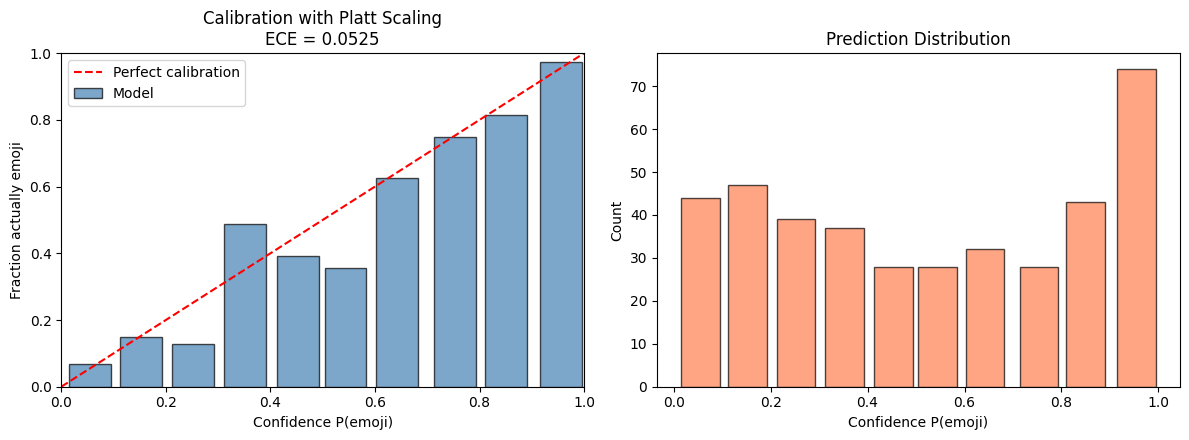

Platt Scaling — Test Accuracy: 0.7725, ECE: 0.0525


In [25]:
from sklearn.linear_model import LogisticRegression
from torch.utils.data import Subset

n_train = len(train_features)
indices = torch.randperm(n_train)
split = int(0.8 * n_train)
train_idx, val_idx = indices[:split], indices[split:]

train_feat_split = train_features[train_idx]
train_lab_split = train_labels[train_idx]
val_feat_split = train_features[val_idx]
val_lab_split = train_labels[val_idx]

model_platt = EmojiClassifier().to(device)
optimizer_platt = torch.optim.Adam(model_platt.parameters(), lr=learning_rate)
criterion_platt = torch.nn.CrossEntropyLoss()
train_dataset_platt = TensorDataset(train_feat_split, train_lab_split)
train_loader_platt = DataLoader(train_dataset_platt, batch_size=batch_size, shuffle=True)

for epoch in range(1, n_epochs + 1):
    model_platt.train()
    for batch_features, batch_labels in train_loader_platt:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        optimizer_platt.zero_grad()
        outputs = model_platt(batch_features)
        loss = criterion_platt(outputs, batch_labels)
        loss.backward()
        optimizer_platt.step()
    if epoch % 5 == 0:
        model_platt.eval()
        with torch.no_grad():
            test_out = model_platt(test_features.to(device))
            acc = (test_out.argmax(1) == test_labels.to(device)).float().mean().item()
        print(f'[Platt] Epoch {epoch}/{n_epochs} - Test Acc: {acc:.4f}')

model_platt.eval()
with torch.no_grad():
    val_logits = model_platt(val_feat_split.to(device)).cpu().numpy()
    val_labels_np = val_lab_split.numpy()

platt_model = LogisticRegression(max_iter=1000, solver='lbfgs')
platt_model.fit(val_logits, val_labels_np)
print(f'Platt parameters — weights: {platt_model.coef_}, bias: {platt_model.intercept_}')

with torch.no_grad():
    test_logits_platt = model_platt(test_features.to(device)).cpu().numpy()

platt_probs = platt_model.predict_proba(test_logits_platt)  # (N, 2)
platt_confidences = torch.tensor(platt_probs[:, 1], dtype=torch.float32)

test_labels_dev = test_labels.to('cpu')
bin_conf_platt, bin_acc_platt, bin_cnt_platt, ece_platt = compute_calibration(platt_confidences, test_labels_dev)
plot_calibration(bin_conf_platt, bin_acc_platt, bin_cnt_platt, ece_platt,
                 title='Calibration with Platt Scaling')
test_acc_platt = (torch.tensor(platt_probs.argmax(1)) == test_labels_dev).float().mean().item()
print(f'Platt Scaling — Test Accuracy: {test_acc_platt:.4f}, ECE: {ece_platt:.4f}')

### L2 Regularization (Weight Decay)
Testing `weight_decay` values of 1e-2, 1e-3, and 1e-4 for min ECE


Weight Decay=1e-04 — Acc: 0.7900, ECE: 0.1387
Weight Decay=1e-03 — Acc: 0.7975, ECE: 0.1136
Weight Decay=1e-02 — Acc: 0.7775, ECE: 0.1066

Best weight_decay: 1e-02 with ECE: 0.1066


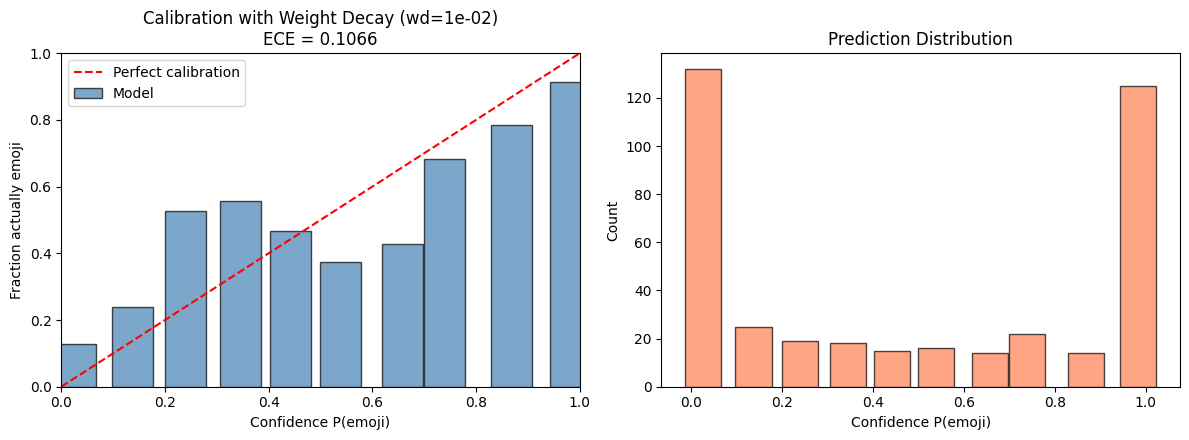

Weight Decay — Test Accuracy: 0.7775, ECE: 0.1066


In [26]:
wd_values = [1e-4, 1e-3, 1e-2]
best_wd = None
best_ece_wd = float('inf')
best_wd_results = None

for wd in wd_values:
    model_wd = EmojiClassifier().to(device)
    optimizer_wd = torch.optim.Adam(model_wd.parameters(), lr=learning_rate, weight_decay=wd)
    criterion_wd = torch.nn.CrossEntropyLoss()
    train_dataset_wd = TensorDataset(train_features, train_labels)
    train_loader_wd = DataLoader(train_dataset_wd, batch_size=batch_size, shuffle=True)

    for epoch in range(1, n_epochs + 1):
        model_wd.train()
        for bf, bl in train_loader_wd:
            bf, bl = bf.to(device), bl.to(device)
            optimizer_wd.zero_grad()
            out = model_wd(bf)
            loss = criterion_wd(out, bl)
            loss.backward()
            optimizer_wd.step()

    model_wd.eval()
    with torch.no_grad():
        test_logits_wd = model_wd(test_features.to(device))
        test_probs_wd = F.softmax(test_logits_wd, dim=1)
        conf_wd = test_probs_wd[:, 1]
        tl_dev = test_labels.to(device)
        bc, ba, bn, ece_wd_val = compute_calibration(conf_wd, tl_dev)
        acc_wd = (test_probs_wd.argmax(1) == tl_dev).float().mean().item()

    print(f'Weight Decay={wd:.0e} — Acc: {acc_wd:.4f}, ECE: {ece_wd_val:.4f}')
    if ece_wd_val < best_ece_wd:
        best_ece_wd = ece_wd_val
        best_wd = wd
        best_wd_results = (bc, ba, bn, ece_wd_val, acc_wd)

print(f'\nBest weight_decay: {best_wd:.0e} with ECE: {best_ece_wd:.4f}')
bc, ba, bn, ece_wd, acc_wd = best_wd_results
plot_calibration(bc, ba, bn, ece_wd,
                 title=f'Calibration with Weight Decay (wd={best_wd:.0e})')
print(f'Weight Decay — Test Accuracy: {acc_wd:.4f}, ECE: {ece_wd:.4f}')

### Focal Loss
<!-- $$\text{FL}(p_t) = -(1 - p_t)^\gamma \log(p_t)$$ -->
with weighting factor gamma = 1, 2, 3

Focal Loss gamma=1.0 — Acc: 0.7675, ECE: 0.0792
Focal Loss gamma=2.0 — Acc: 0.7875, ECE: 0.0363
Focal Loss gamma=3.0 — Acc: 0.7775, ECE: 0.0712

Best gamma: 2.0 with ECE: 0.0363


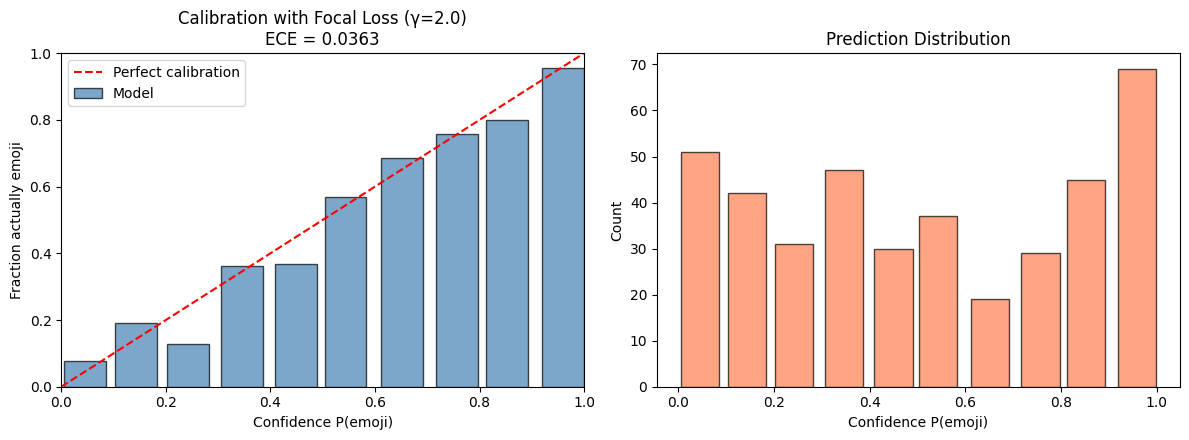

Focal Loss — Test Accuracy: 0.7875, ECE: 0.0363


In [27]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

gamma_values = [1.0, 2.0, 3.0]
best_gamma = None
best_ece_fl = float('inf')
best_fl_results = None

for gamma in gamma_values:
    model_fl = EmojiClassifier().to(device)
    optimizer_fl = torch.optim.Adam(model_fl.parameters(), lr=learning_rate)
    criterion_fl = FocalLoss(gamma=gamma)
    train_dataset_fl = TensorDataset(train_features, train_labels)
    train_loader_fl = DataLoader(train_dataset_fl, batch_size=batch_size, shuffle=True)

    for epoch in range(1, n_epochs + 1):
        model_fl.train()
        for bf, bl in train_loader_fl:
            bf, bl = bf.to(device), bl.to(device)
            optimizer_fl.zero_grad()
            out = model_fl(bf)
            loss = criterion_fl(out, bl)
            loss.backward()
            optimizer_fl.step()

    model_fl.eval()
    with torch.no_grad():
        test_logits_fl = model_fl(test_features.to(device))
        test_probs_fl = F.softmax(test_logits_fl, dim=1)
        conf_fl = test_probs_fl[:, 1]
        tl_dev = test_labels.to(device)
        bc, ba, bn, ece_fl_val = compute_calibration(conf_fl, tl_dev)
        acc_fl = (test_probs_fl.argmax(1) == tl_dev).float().mean().item()

    print(f'Focal Loss gamma={gamma:.1f} — Acc: {acc_fl:.4f}, ECE: {ece_fl_val:.4f}')
    if ece_fl_val < best_ece_fl:
        best_ece_fl = ece_fl_val
        best_gamma = gamma
        best_fl_results = (bc, ba, bn, ece_fl_val, acc_fl)

print(f'\nBest gamma: {best_gamma:.1f} with ECE: {best_ece_fl:.4f}')
bc, ba, bn, ece_fl, acc_fl = best_fl_results
plot_calibration(bc, ba, bn, ece_fl,
                 title=f'Calibration with Focal Loss (γ={best_gamma:.1f})')
print(f'Focal Loss — Test Accuracy: {acc_fl:.4f}, ECE: {ece_fl:.4f}')

### Mixup

Mixup with $\alpha \in \{0.1, 0.2, 0.4\}$.

Mixup alpha=0.1 — Acc: 0.7675, ECE: 0.1066
Mixup alpha=0.2 — Acc: 0.7775, ECE: 0.0866
Mixup alpha=0.4 — Acc: 0.7675, ECE: 0.0805

Best alpha: 0.4 with ECE: 0.0805


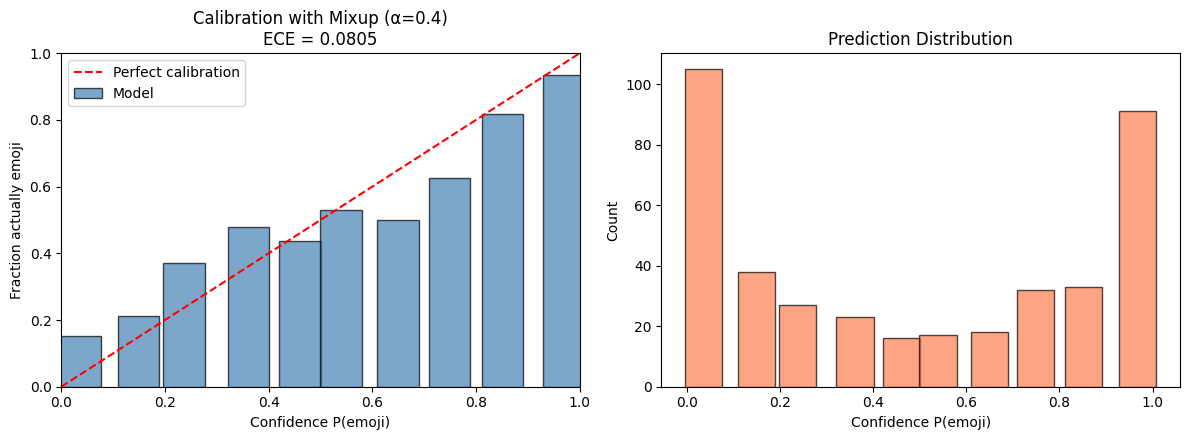

Mixup — Test Accuracy: 0.7675, ECE: 0.0805


In [28]:
alpha_values = [0.1, 0.2, 0.4]
best_alpha = None
best_ece_mix = float('inf')
best_mix_results = None

for alpha in alpha_values:
    model_mix = EmojiClassifier().to(device)
    optimizer_mix = torch.optim.Adam(model_mix.parameters(), lr=learning_rate)
    train_dataset_mix = TensorDataset(train_features, train_labels)
    train_loader_mix = DataLoader(train_dataset_mix, batch_size=batch_size, shuffle=True)

    for epoch in range(1, n_epochs + 1):
        model_mix.train()
        for bf, bl in train_loader_mix:
            bf, bl = bf.to(device), bl.to(device)
            lam = np.random.beta(alpha, alpha)
            idx = torch.randperm(bf.size(0)).to(device)
            mixed_x = lam * bf + (1 - lam) * bf[idx]
            y_onehot = F.one_hot(bl, 2).float()
            mixed_y = lam * y_onehot + (1 - lam) * y_onehot[idx]
            optimizer_mix.zero_grad()
            out = model_mix(mixed_x)
            loss = -(mixed_y * F.log_softmax(out, dim=1)).sum(1).mean()
            loss.backward()
            optimizer_mix.step()

    model_mix.eval()
    with torch.no_grad():
        test_logits_mix = model_mix(test_features.to(device))
        test_probs_mix = F.softmax(test_logits_mix, dim=1)
        conf_mix = test_probs_mix[:, 1]
        tl_dev = test_labels.to(device)
        bc, ba, bn, ece_mix_val = compute_calibration(conf_mix, tl_dev)
        acc_mix = (test_probs_mix.argmax(1) == tl_dev).float().mean().item()

    print(f'Mixup alpha={alpha:.1f} — Acc: {acc_mix:.4f}, ECE: {ece_mix_val:.4f}')
    if ece_mix_val < best_ece_mix:
        best_ece_mix = ece_mix_val
        best_alpha = alpha
        best_mix_results = (bc, ba, bn, ece_mix_val, acc_mix)

print(f'\nBest alpha: {best_alpha:.1f} with ECE: {best_ece_mix:.4f}')
bc, ba, bn, ece_mix, acc_mix = best_mix_results
plot_calibration(bc, ba, bn, ece_mix,
                 title=f'Calibration with Mixup (\u03b1={best_alpha:.1f})')
print(f'Mixup — Test Accuracy: {acc_mix:.4f}, ECE: {ece_mix:.4f}')

### Comparison 

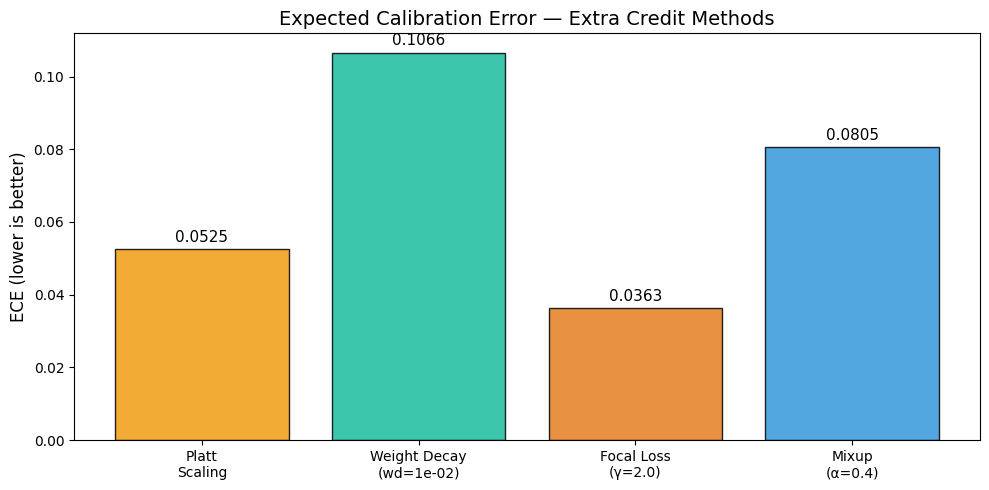

Method                         ECE
-----------------------------------
Platt Scaling               0.0525
Weight Decay (wd=1e-02)     0.1066
Focal Loss (γ=2.0)          0.0363
Mixup (α=0.4)               0.0805


In [29]:
all_methods = [
    'Platt\nScaling',
    f'Weight Decay\n(wd={best_wd:.0e})',
    f'Focal Loss\n(\u03b3={best_gamma:.1f})',
    f'Mixup\n(\u03b1={best_alpha:.1f})'
]
all_eces = [
    ece_platt.cpu().item() if hasattr(ece_platt, 'cpu') else float(ece_platt),
    ece_wd.cpu().item() if hasattr(ece_wd, 'cpu') else float(ece_wd),
    ece_fl.cpu().item() if hasattr(ece_fl, 'cpu') else float(ece_fl),
    ece_mix.cpu().item() if hasattr(ece_mix, 'cpu') else float(ece_mix),
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#f39c12', '#1abc9c', '#e67e22', '#3498db']
bars = ax.bar(all_methods, all_eces, color=colors, edgecolor='black', alpha=0.85)
ax.set_ylabel('ECE (lower is better)', fontsize=12)
ax.set_title('Expected Calibration Error — Extra Credit Methods', fontsize=14)
for bar, e in zip(bars, all_eces):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{e:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f'{"Method":<25} {"ECE":>8}')
print('-' * 35)
for m, e in zip(all_methods, all_eces):
    print(f'{m.replace(chr(10), " "):<25} {e:>8.4f}')

## Submission

Export this notebook to PDF and submit on Canvas.
```python
!jupyter nbconvert --to pdf --output=yourname_hw2.pdf hw2.ipynb
```